In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import re
import warnings

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'matplotlib'

## 1. Data load & clean

In [ ]:
DATA_FILE = 'Medicine.csv'   
TODAY = pd.Timestamp.today().normalize()

# Fixed: Pass DATA_FILE variable instead of unquoted Medicine.csv
df = pd.read_csv(DATA_FILE)
df.columns = df.columns.str.strip()

def parse_date(s):
    s = str(s).strip()
    s = re.sub(r'^(\d{1,2})/(\d{2})(\d{4})$', r'\1/\2/\3', s)  
    s = re.sub(r'/20(20\d{2})$', r'/\1', s)                         
    if re.fullmatch(r'\d{4}[-/]\d{1,2}[-/]\d{1,2}', s):
        cands = [('%Y-%m-%d', s.replace('/', '-'))]
    elif re.fullmatch(r'\d{1,2}/\d{1,2}/\d{4}', s):
        cands = [('%d/%m/%Y', s), ('%m/%d/%Y', s)]
    elif re.fullmatch(r'\d{1,2}/\d{1,2}/\d{2}', s):
        cands = [('%d/%m/%y', s), ('%y/%m/%d', s)]
    else:
        cands = []
    for fmt, val in cands:
        try:
            d = pd.to_datetime(val, format=fmt)
            if d <= TODAY:
                return d
        except Exception:
            pass
    return pd.NaT

df['Date'] = df['Date'].map(parse_date)

df['Quantity'] = df['Quantity'].astype(str).str.replace('+', '', regex=False)
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

df['Medicine Name'] = df['Medicine Name'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
canon = df.groupby(df['Medicine Name'].str.lower())['Medicine Name'].agg(lambda x: x.value_counts().index[0])
df['Medicine Name'] = df['Medicine Name'].str.lower().map(canon)

df = df.dropna(subset=['Date', 'Quantity'])
df = df[df['Quantity'] > 0]

mcount = df.groupby(df['Date'].dt.to_period('M')).size()
df = df[df['Date'].dt.to_period('M').map(mcount) >= 0.2 * mcount.median()]
last_day = df['Date'].max()
if last_day != last_day + pd.offsets.MonthEnd(0):          
    df = df[df['Date'].dt.to_period('M') < last_day.to_period('M')]

print(f"Rows: {len(df)} | Medicines: {df['Medicine Name'].nunique()}")
print(f"Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")

Rows: 46181 | Medicines: 3315
Date range: 2025-01-01 -> 2026-07-31


## 2. Top 100 medicines (visualization)

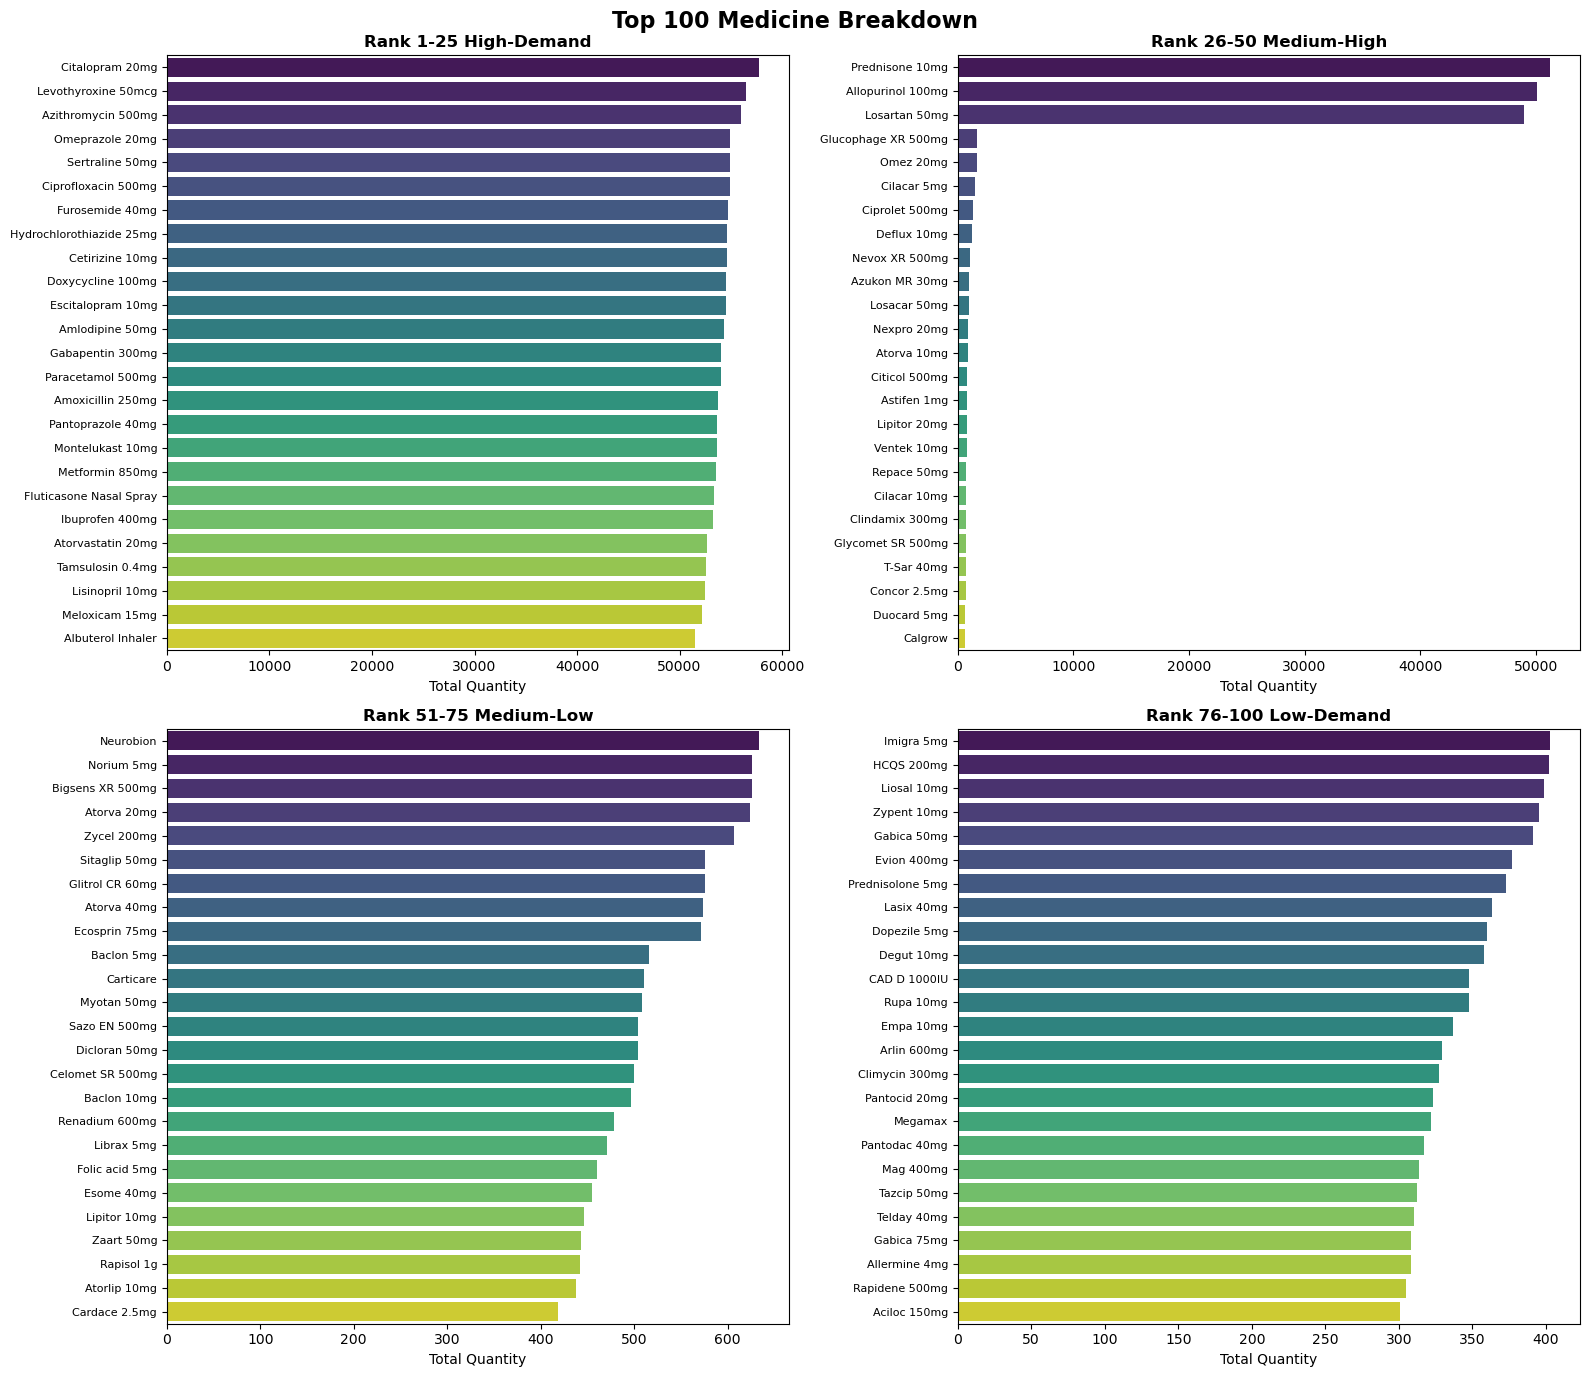

In [ ]:
top_100 = df.groupby('Medicine Name')['Quantity'].sum().sort_values(ascending=False).head(100)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
chunks = [("Rank 1-25 High-Demand", top_100.iloc[0:25]),
          ("Rank 26-50 Medium-High", top_100.iloc[25:50]),
          ("Rank 51-75 Medium-Low", top_100.iloc[50:75]),
          ("Rank 76-100 Low-Demand", top_100.iloc[75:100])]
for idx, (title, data) in enumerate(chunks):
    if len(data) == 0:
        axes[idx].axis('off'); continue
    sns.barplot(x=data.values, y=data.index, hue=data.index, ax=axes[idx], palette='viridis', legend=False)
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Total Quantity'); axes[idx].set_ylabel('')
    axes[idx].tick_params(axis='y', labelsize=8)
plt.suptitle('Top 100 Medicine Breakdown', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Monthly dataset + Lag features
හැම ඖෂධයකටම මාසයෙන් මාසය (මාසයක විකුණුම් නැත්නම් 0) තනා, ඉන්පසු කලින් මාස වල අගයන් (Lag) එකතු කරනවා.

In [ ]:
df['Month_Start'] = df['Date'].dt.to_period('M').dt.to_timestamp()

monthly = (df.groupby(['Medicine Name', 'Month_Start'])['Quantity'].sum().reset_index()
             .set_index('Month_Start')
             .groupby('Medicine Name')['Quantity']
             .resample('MS').sum()          
             .reset_index()
             .sort_values(['Medicine Name', 'Month_Start'])
             .reset_index(drop=True))

monthly['Year'] = monthly['Month_Start'].dt.year
monthly['Month'] = monthly['Month_Start'].dt.month

grp = monthly.groupby('Medicine Name')['Quantity']
monthly['Monthly_Lag_1'] = grp.shift(1)
monthly['Monthly_Lag_2'] = grp.shift(2)
monthly['Monthly_Rolling_3'] = grp.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())

def get_season(month):
    if month in [5, 6, 7, 8, 9]:
        return 'SouthWest_Monsoon'
    elif month in [12, 1, 2]:
        return 'NorthEast_Monsoon'
    return 'Inter_Monsoon'

monthly['Season'] = monthly['Month'].apply(get_season)

data = monthly.dropna(subset=['Monthly_Lag_1', 'Monthly_Lag_2']).reset_index(drop=True)
print(f"Monthly records: {len(data)} | Medicines: {data['Medicine Name'].nunique()}")
data.head()

Monthly records: 5633 | Medicines: 733


,Medicine Name,Month_Start,Quantity,Year,Month,Monthly_Lag_1,Monthly_Lag_2,Monthly_Rolling_3,Season
0,ATM Sy,2025-05-01,0.0,2025,5,0.0,1.0,0.500000,SouthWest_Monsoon
1,ATM Sy,2025-06-01,0.0,2025,6,0.0,0.0,0.333333,SouthWest_Monsoon
2,ATM Sy,2025-07-01,0.0,2025,7,0.0,0.0,0.000000,SouthWest_Monsoon
3,ATM Sy,2025-08-01,0.0,2025,8,0.0,0.0,0.000000,SouthWest_Monsoon
4,ATM Sy,2025-09-01,0.0,2025,9,0.0,0.0,0.000000,SouthWest_Monsoon


## 4. කාලය අනුව Train / Test split (80% / 20%)

In [ ]:
all_months = np.sort(data['Month_Start'].unique())
cutoff = all_months[int(len(all_months) * 0.8) - 1]

train_mask = data['Month_Start'] <= cutoff
print(f"Train: {data.loc[train_mask,'Month_Start'].min().date()} -> {pd.Timestamp(cutoff).date()}  ({train_mask.sum()} rows)")
print(f"Test : {data.loc[~train_mask,'Month_Start'].min().date()} -> {data.loc[~train_mask,'Month_Start'].max().date()}  ({(~train_mask).sum()} rows)")

avg_train = data[train_mask].groupby('Medicine Name')['Quantity'].mean()
data['Med_Avg_Demand'] = data['Medicine Name'].map(avg_train).fillna(avg_train.mean())

NUMERIC = ['Year', 'Month', 'Monthly_Lag_1', 'Monthly_Lag_2', 'Monthly_Rolling_3', 'Med_Avg_Demand']

def build_X(frame):
    X = pd.get_dummies(frame[NUMERIC + ['Medicine Name', 'Season']],
                       columns=['Medicine Name', 'Season'], dtype=float)
    return X.astype(float)

X_all = build_X(data)
y_all = data['Quantity']

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test,  y_test  = X_all[~train_mask], y_all[~train_mask]
print("Feature count:", X_all.shape[1])

Train: 2025-03-01 -> 2026-03-01  (5348 rows)
Test : 2026-04-01 -> 2026-07-01  (285 rows)
Feature count: 742


## 5. Model Training (Polynomial + LassoCV)

In [ ]:
poly_cols = ['Year', 'Month', 'Monthly_Lag_1', 'Monthly_Lag_2', 'Monthly_Rolling_3']

poly_transformer = ColumnTransformer(
    transformers=[('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False), poly_cols)],
    remainder='passthrough'
)

X_train_poly = poly_transformer.fit_transform(X_train)
X_test_poly = poly_transformer.transform(X_test)

final_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('model', LassoCV(n_alphas=100, cv=5, random_state=42, max_iter=50000))
])

final_model.fit(X_train_poly, y_train)         
print("Best alpha:", final_model.named_steps['model'].alpha_)

y_train_pred = np.maximum(0, final_model.predict(X_train_poly))
y_test_pred = np.maximum(0, final_model.predict(X_test_poly))

Best alpha: 0.7605247636451037


## 6. Evaluation

In [ ]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    return {
        'WAPE Accuracy (%)': 100 - np.sum(np.abs(y_true - y_pred)) / max(np.sum(y_true), 1e-9) * 100,
        'R2 Score (%)': r2_score(y_true, y_pred) * 100,
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
    }

m_train, m_test = metrics(y_train, y_train_pred), metrics(y_test, y_test_pred)
print(pd.DataFrame({'Train': m_train, 'Test': m_test}).round(2))

                      Train      Test
WAPE Accuracy (%)     83.80     88.19
R2 Score (%)          98.03     96.95
MAE                   33.25    131.56
MSE                10122.18  58564.18
RMSE                 100.61    242.00


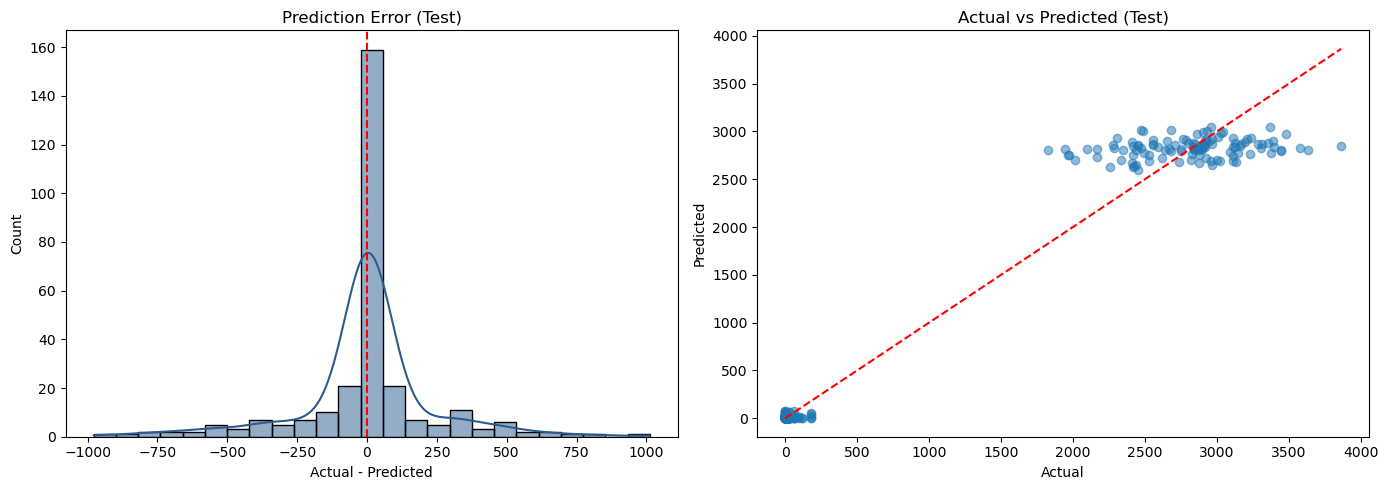

In [ ]:
residuals = y_test - y_test_pred
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, bins=25, color='#2b5c8f')
plt.axvline(0, color='red', linestyle='--'); plt.title('Prediction Error (Test)')
plt.xlabel('Actual - Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5)
lim = [0, max(y_test.max(), y_test_pred.max())]
plt.plot(lim, lim, 'r--'); plt.title('Actual vs Predicted (Test)')
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.tight_layout(); plt.show()

## 7. SARIMA සංසන්දනය (විකල්ප - Save නොකරයි)
වැඩිපුරම විකුණෙන ඖෂධ 3 සඳහා, මාස 24කට වැඩි දත්ත තිබේ නම් පමණක්.

In [ ]:
sarima_results = {}
for med in top_100.index[:3]:
    s = monthly[monthly['Medicine Name'] == med].set_index('Month_Start')['Quantity']
    if len(s) < 24:
        print(f"Skipping '{med}': data too short ({len(s)} months)"); continue
    n_train = int(len(s) * 0.8)
    s_train, s_test = s.iloc[:n_train], s.iloc[n_train:]
    try:
        fit = SARIMAX(s_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        pred = np.maximum(0, fit.forecast(steps=len(s_test)))
        sarima_results[med] = {
            'WAPE Accuracy (%)': round(100 - np.sum(np.abs(s_test - pred)) / max(np.sum(s_test), 1e-9) * 100, 2),
            'MAE': round(mean_absolute_error(s_test, pred), 2),
            'RMSE': round(np.sqrt(mean_squared_error(s_test, pred)), 2)}
    except Exception as e:
        print(f"SARIMA failed for '{med}': {e}")
if sarima_results:
    display(pd.DataFrame(sarima_results).T)
else:
    print("SARIMA was not run: data is less than 24 months (minimum of 2 years required for seasonal=12).")

Skipping 'Citalopram 20mg': data too short (19 months)
Skipping 'Levothyroxine 50mcg': data too short (19 months)
Skipping 'Azithromycin 500mg': data too short (19 months)
SARIMA was not run: data is less than 24 months (minimum of 2 years required for seasonal=12).


## 8. අවසන් Model එක සියලු දත්ත වලින් නැවත Train කිරීම
Evaluation එකෙන් පසු, අලුත්ම මාස ද ඇතුළත්ව final model එක train කරනවා.

In [ ]:
avg_all = data.groupby('Medicine Name')['Quantity'].mean()
data['Med_Avg_Demand'] = data['Medicine Name'].map(avg_all)
X_full = build_X(data)
assert list(X_full.columns) == list(X_all.columns)

final_model.fit(poly_transformer.fit_transform(X_full), y_all)
feature_columns = X_full.columns.tolist()
avg_demand_db = avg_all.to_dict()

forecast_input_db = {}
last_month = monthly['Month_Start'].max()          
next_month = last_month + pd.DateOffset(months=1)  
for med, g in monthly.groupby('Medicine Name'):
    s_ = g.set_index('Month_Start')['Quantity']
    
    q = s_.reindex(pd.date_range(s_.index.min(), last_month, freq='MS'), fill_value=0).values
    forecast_input_db[med] = {
        'Year': int(next_month.year), 'Month': int(next_month.month),
        'Monthly_Lag_1': float(q[-1]),
        'Monthly_Lag_2': float(q[-2]) if len(q) > 1 else float(q[-1]),
        'Monthly_Rolling_3': float(q[-3:].mean()),
    }
forecast_input_db = {m: v for m, v in forecast_input_db.items() if m in avg_demand_db}

if os.path.exists(STOCK_FILE):
    st = pd.read_csv(STOCK_FILE); st.columns = st.columns.str.strip()
    inventory_db = dict(zip(st['Medicine Name'].str.strip(), pd.to_numeric(st['Current Stock'], errors='coerce').fillna(0)))
    print(f"Loaded real stock for {len(inventory_db)} medicines.")
else:
    inventory_db = {m: float(v['Monthly_Rolling_3']) for m, v in forecast_input_db.items()}
    print("WARNING: 'Current stock.csv' not found -> stock = past 3 months average (placeholder). Use actual stock values.")

## 9. Save (server.py සඳහා එක file එකක්)

In [ ]:
joblib.dump({
    'model': final_model,
    'poly_transformer': poly_transformer,
    'feature_columns': feature_columns,
    'inventory_db': inventory_db,
    'avg_demand_db': avg_demand_db,
    'forecast_input_db': forecast_input_db,
}, 'medicine_demand_model.pkl')
print("Saved -> medicine_demand_model.pkl")

Saved -> medicine_demand_model.pkl
